# Classification of HCC samples with Biopsy and Resection samples

#### In this notebook I perform comparison with biopsy/resection samples to the classification data - The input of this analysis is counts data (BvR combined with Class), aligned in SE mode, length 50. 

#### Annotate genes with RNA_biotype and gene name -  Keep only Protein coding genes

####  plot PCA, Clustermap

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import re
import math
import pickle
from pprint import pprint

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy import stats

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.pyplot import gcf
from matplotlib import cm, colors

from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats

%matplotlib inline
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

sns.set(font_scale=1.5)
sns.set_style("ticks")

In [14]:
# New sample mapping with clinical features
meta = pd.read_csv('../sample_mapping_BvR.csv')
# We only do HCC
meta = meta[meta['Tumor diagnosis'] == 'HCC']
# Only take patients were we have all transcriptome samples
rna_cols = ['Biopsy_nt_transcriptome', 'Resection_nt_transcriptome']
meta = meta.dropna(subset=rna_cols)
meta = meta[(meta['Patient ID'] != 'M') & (meta['Patient ID'] != 'M')]
meta = meta[(meta['Patient ID'] != 'C') & (meta['Patient ID'] != 'C')]
meta.head()

,Patient ID,Biopsy_nt_transcriptome,Biopsy_tu_transcriptome,Resection_nt_transcriptome,Resection_tu_transcriptome,Biopsy_nt_proteome,Biopsy_tu_proteome,Resection_nt_protome,Resection_tu_protome,Biopsy_nt_phospho,Biopsy_tu_phospho,Resection_nt_phospho,Resection_tu_phospho,Age,Sex,PreBx_MELD,PreBx_ALAT,PreBx_ASAT,PreBx_GGT,PreBx_AP,PreBx_Albumin,PreBx_Bilirubin,PreBx_Quick,PreBx_Hb,PreBx_Lc,PreBx_Tc,PreBx_CRP,PreBx_AFP,PreOP_MELD,PreOP_ALAT,PreOP_ASAT,PreOP_GGT,PreOP_AP,PreOP_Albumin,PreOP_Bilirubin,PreOP_Quick,PreOP_Hb,PreOP_Lc,PreOP_Tc,PreOP_CRP,PreOP_AFP,CHILD,BCLC,Nr of nodules,Max nodule size,Time between resection and biopsy,Total surgery time = ischemia time,Tumor diagnosis,Biopsy_nt_hepatocyte,Resection_nt_hepatocyte,Biopsy_nt_stroma,Resection_nt_stroma,Biopsy_tu_tumor,Resection_tu_tumor,Biopsy_tu_stroma,Resection_tu_stroma,Biopsy_tu_necrosis,Resection_tu_necrosis,Biopsy_tu_nontumor,Resection_tu_nontumor
3,B,BSSE_QGF_129466,BSSE_QGF_129467,BSSE_QGF_129468,BSSE_QGF_129469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59.0,M,12.0,53.0,55.0,46.0,137.0,36.0,43.0,72.0,141.0,4.0,54.0,3.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,1,70.0,43.0,NaN,HCC,84.0,94.0,16.0,6.0,86.0,99.0,8.0,0.0,0.0,1.0,5.0,0.0
7,D,BSSE_QGF_182052,BSSE_QGF_182053,BSSE_QGF_182082,BSSE_QGF_182083,011_BR-LF-3_C21,012_BR-LF-3_C21,032_BR-LF-3_C21,033r_BR-LF-3_C21,011_BR-LF-3P_PO4_C21,012_BR-LF-3P_PO4_C21,032_BR-LF-3P_PO4_C21,033_BR-LF-3P_PO4_C21,70.0,F,6.0,29.0,22.0,23.0,82.0,41.0,9.0,94.0,147.0,11.0,254.0,0.3,2.0,6.0,22.0,20.0,22.0,93.0,42.0,11.0,95.0,139.0,11.0,284.0,0.3,NaN,NaN,A,1,23.0,29.0,87.0,HCC,84.0,87.0,16.0,13.0,47.0,97.0,29.0,3.0,0.0,0.0,24.0,0.0
9,E,BSSE_QGF_145476,BSSE_QGF_145477,BSSE_QGF_145478,BSSE_QGF_145479,075_BR-LF-3_C21,076_BR-LF-3_C21,087_BR-LF-3_C21,088_BR-LF-3_C21,075_BR-LF-3P_PO4_C21,076_BR-LF-3P_PO4_C21,087_BR-LF-3P_PO4_C21,088_BR-LF-3P_PO4_C21,79.0,M,6.0,18.0,26.0,167.0,80.0,39.0,10.0,94.0,127.0,5.0,139.0,3.0,12.0,7.0,26.0,28.0,149.0,83.0,38.0,9.0,87.0,139.0,6.0,184.0,2.0,NaN,NaN,A,2,29.0,31.0,149.0,HCC,93.0,90.0,7.0,10.0,61.0,99.0,19.0,1.0,5.0,0.0,15.0,0.0
11,F,BSSE_QGF_145472,BSSE_QGF_145473,BSSE_QGF_145474,BSSE_QGF_145475,077_BR-LF-3_C21,078_BR-LF-3_C21,089_BR-LF-3_C21,090_BR-LF-3_C21,077_BR-LF-3P_PO4_C21,078_BR-LF-3P_PO4_C21,089_BR-LF-3P_PO4_C21,090_BR-LF-3P_PO4_C21,49.0,M,6.0,30.0,29.0,59.0,53.0,38.0,13.0,103.0,161.0,6.0,196.0,1.0,2.0,6.0,25.0,26.0,49.0,56.0,39.0,5.0,115.0,154.0,5.0,209.0,1.0,NaN,NaN,A,1,35.0,11.0,212.0,HCC,99.0,97.0,1.0,3.0,75.0,96.0,10.0,4.0,14.0,0.0,0.0,0.0
15,H,BSSE_QGF_129476,BSSE_QGF_129477,BSSE_QGF_129480,BSSE_QGF_129481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,69.0,F,11.0,24.0,31.0,23.0,80.0,33.0,25.0,65.0,127.0,4.0,87.0,1.0,NaN,9.0,28.0,35.0,53.0,95.0,36.0,21.0,69.0,117.0,4.0,98.0,NaN,NaN,NaN,A,1,50.0,20.0,64.0,HCC,68.0,82.0,32.0,18.0,98.0,96.0,2.0,4.0,0.0,0.0,0.0,0.0


In [15]:
# Import data

raw_bvr = pd.read_csv('../counts_080725.out', skiprows=1, sep='\t', index_col=0)
# Drop gene info
raw_bvr = raw_bvr.iloc[:,5:]
# Change column names
raw_bvr.columns = raw_bvr.columns.str.split('/').str[-1].str.replace('Aligned.sortedByCoord.out.bam', '')

# Check if we have all rna seq samples in the counts table
found = []
for group in rna_cols:
    for seq_id in meta[group]:
        if seq_id in raw_bvr.columns:
            found.append(seq_id)
        else:
            print('missing:', seq_id)
            
# Extras
extras = []
for seq_id in raw_bvr.columns:
    if seq_id in found:
        continue
    else:
        print('extra:', seq_id)
        extras.append(seq_id)
raw_bvr = raw_bvr.drop(extras, axis=1)

raw_bvr.head()

extra: BSSE_QGF_129467
extra: BSSE_QGF_129469
extra: BSSE_QGF_129475
extra: BSSE_QGF_129477
extra: BSSE_QGF_129479
extra: BSSE_QGF_129481
extra: BSSE_QGF_145457
extra: BSSE_QGF_145458
extra: BSSE_QGF_145461
extra: BSSE_QGF_145463
extra: BSSE_QGF_145465
extra: BSSE_QGF_145466
extra: BSSE_QGF_145473
extra: BSSE_QGF_145475
extra: BSSE_QGF_145477
extra: BSSE_QGF_145479
extra: BSSE_QGF_145480
extra: BSSE_QGF_145481
extra: BSSE_QGF_182046
extra: BSSE_QGF_182047
extra: BSSE_QGF_182048
extra: BSSE_QGF_182049
extra: BSSE_QGF_182053
extra: BSSE_QGF_182055
extra: BSSE_QGF_182056
extra: BSSE_QGF_182057
extra: BSSE_QGF_182065
extra: BSSE_QGF_182067
extra: BSSE_QGF_182071
extra: BSSE_QGF_182073
extra: BSSE_QGF_182075
extra: BSSE_QGF_182077
extra: BSSE_QGF_182080
extra: BSSE_QGF_182081
extra: BSSE_QGF_182083
extra: BSSE_QGF_182085
extra: BSSE_QGF_182087
extra: BSSE_QGF_182088
extra: BSSE_QGF_182091
extra: BSSE_QGF_182092
extra: BSSE_QGF_182099
extra: BSSE_QGF_182101
extra: BSSE_QGF_182103
extra: BSSE

,BSSE_QGF_129466,BSSE_QGF_129468,BSSE_QGF_129474,BSSE_QGF_129476,BSSE_QGF_129478,BSSE_QGF_129480,BSSE_QGF_129482,BSSE_QGF_145460,BSSE_QGF_145462,BSSE_QGF_145472,BSSE_QGF_145474,BSSE_QGF_145476,BSSE_QGF_145478,BSSE_QGF_182052,BSSE_QGF_182054,BSSE_QGF_182064,BSSE_QGF_182066,BSSE_QGF_182070,BSSE_QGF_182072,BSSE_QGF_182074,BSSE_QGF_182076,BSSE_QGF_182082,BSSE_QGF_182084,BSSE_QGF_182098,BSSE_QGF_182100,BSSE_QGF_182102,BSSE_QGF_182104,BSSE_QGF_182106,BSSE_QGF_182110,BSSE_QGF_55728
Geneid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ENSG00000160072,298,285,158,289,169,113,154,165,183,69,41,70,135,132,200,240,286,68,192,186,116,181,271,505,6,312,201,261,445,127
ENSG00000279928,1,0,0,1,2,0,1,6,1,0,0,0,0,2,3,1,0,0,1,0,3,0,0,5,0,0,0,0,0,2
ENSG00000228037,13,10,12,24,3,3,2,17,6,2,0,5,2,11,5,5,10,10,8,9,12,5,1,6,0,10,0,5,8,14
ENSG00000142611,40,50,18,92,19,14,4,35,31,4,3,0,0,6,1,1,18,5,4,17,3,14,8,28,0,19,13,13,5,4
ENSG00000284616,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [112]:
# Import data

raw_class = pd.read_csv('../counts_with_class_norm.out', skiprows=1, sep='\t', index_col=0)
# Drop gene info
raw_class = raw_class.iloc[:,5:]
# Change column names
raw_class.columns = raw_class.columns.str.split('/').str[-1].str.replace('Aligned.sortedByCoord.out.bam', '')
raw_class.head()

,BSSE_QGF_107000,BSSE_QGF_107012,BSSE_QGF_107022,BSSE_QGF_107027,BSSE_QGF_107036,BSSE_QGF_107057,BSSE_QGF_107062,BSSE_QGF_34364,BSSE_QGF_34368,BSSE_QGF_34370,BSSE_QGF_34374,BSSE_QGF_34376,BSSE_QGF_34378,BSSE_QGF_34380,BSSE_QGF_34382,BSSE_QGF_34384,BSSE_QGF_34386,BSSE_QGF_34388,BSSE_QGF_34390,BSSE_QGF_34392,BSSE_QGF_34397,BSSE_QGF_34399,BSSE_QGF_34403,BSSE_QGF_34405,BSSE_QGF_34407,BSSE_QGF_34409,BSSE_QGF_34411,BSSE_QGF_34413,BSSE_QGF_34415,BSSE_QGF_34419,BSSE_QGF_34423,BSSE_QGF_34425,BSSE_QGF_34430,BSSE_QGF_34432,BSSE_QGF_34434,BSSE_QGF_34436,BSSE_QGF_34438,BSSE_QGF_34440,BSSE_QGF_34442,BSSE_QGF_34444,BSSE_QGF_34446,BSSE_QGF_34448,BSSE_QGF_34450,BSSE_QGF_34452,BSSE_QGF_34454,BSSE_QGF_34456,BSSE_QGF_34458,BSSE_QGF_34462,BSSE_QGF_34464,BSSE_QGF_34466,BSSE_QGF_34468,BSSE_QGF_34479,BSSE_QGF_34481,BSSE_QGF_34482,BSSE_QGF_34485,BSSE_QGF_34494,BSSE_QGF_35689,BSSE_QGF_35697,BSSE_QGF_35703,BSSE_QGF_54952,BSSE_QGF_54953,BSSE_QGF_54954,BSSE_QGF_54956,BSSE_QGF_54960,BSSE_QGF_54962,BSSE_QGF_54966,BSSE_QGF_54971,BSSE_QGF_54972,BSSE_QGF_54974,BSSE_QGF_54978,BSSE_QGF_54983,BSSE_QGF_54991,BSSE_QGF_54993,BSSE_QGF_54996,BSSE_QGF_54998,BSSE_QGF_55003,BSSE_QGF_55005,BSSE_QGF_55011,BSSE_QGF_55015,BSSE_QGF_55018,BSSE_QGF_55023,BSSE_QGF_55025,BSSE_QGF_55027,BSSE_QGF_55033,BSSE_QGF_55039,BSSE_QGF_55043,BSSE_QGF_55697,BSSE_QGF_55703,BSSE_QGF_55705,BSSE_QGF_55707,BSSE_QGF_55711,BSSE_QGF_55718,BSSE_QGF_55720,BSSE_QGF_55724,BSSE_QGF_55726,BSSE_QGF_55728,BSSE_QGF_55734,BSSE_QGF_55736,BSSE_QGF_55738,BSSE_QGF_55746,BSSE_QGF_55750,BSSE_QGF_55755,BSSE_QGF_55760,BSSE_QGF_55762,BSSE_QGF_79903,BSSE_QGF_79907
Geneid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ENSG00000160072,77,129,134,108,134,108,141,108,397,317,171,257,162,321,197,263,247,175,189,213,549,239,217,226,273,155,240,312,208,268,188,4,225,68,304,416,236,7,122,336,192,306,189,329,83,203,144,166,185,394,153,352,326,453,233,13,223,128,250,196,152,91,96,150,167,269,299,223,86,193,211,240,148,111,162,120,74,211,151,107,324,172,184,135,123,195,21,102,107,105,164,259,126,199,115,127,115,137,121,163,146,112,112,134,353,167
ENSG00000279928,0,5,0,0,2,3,0,0,2,1,0,4,2,2,0,2,3,2,4,0,1,0,1,1,3,3,1,8,4,0,3,0,0,2,1,1,3,0,2,3,4,1,5,1,0,0,0,2,1,0,1,6,8,4,0,0,0,0,0,0,2,0,0,1,2,3,0,6,0,2,1,2,0,0,2,2,0,4,2,2,0,0,0,1,1,0,0,1,0,1,3,0,3,0,2,2,0,1,0,4,1,0,3,1,0,2
ENSG00000228037,5,7,15,13,6,11,10,6,19,8,8,8,4,15,8,6,12,9,9,17,13,11,4,9,11,12,13,14,9,22,19,0,12,9,11,15,7,0,5,14,9,19,11,22,4,8,1,10,9,19,8,24,12,9,21,0,8,15,5,11,9,18,9,11,22,20,3,15,7,18,8,11,6,28,5,5,18,28,23,21,15,5,9,8,2,36,12,10,12,11,15,33,9,22,10,14,17,18,9,10,4,13,16,8,11,4
ENSG00000142611,13,5,6,22,4,0,19,2,22,34,14,55,11,19,25,21,23,6,6,23,43,6,28,13,38,22,14,45,58,32,8,0,20,12,62,34,30,1,17,88,41,49,12,97,9,33,11,16,28,13,8,69,73,8,14,8,11,18,8,32,13,11,10,9,16,29,5,35,4,11,62,35,5,10,0,7,19,44,0,2,16,0,3,9,12,15,8,7,20,0,20,20,3,16,14,4,4,13,9,21,9,7,16,23,15,2
ENSG00000284616,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [113]:
# Check for duplicates
drop=[]
for group in rna_cols:
    for seq_id in meta[group]:
        if seq_id in raw_class.columns.tolist():
            print(seq_id)
            drop.append(seq_id)
raw_class = raw_class.drop(drop, axis=1)

BSSE_QGF_55728


In [114]:
drop=[]
for col in raw_bvr.columns:
    if col in raw_class.columns.tolist():
        print(col)
        drop.append(col)
        
raw_class = raw_class.drop(drop, axis=1)

In [115]:
# Drop outliers

raw_class = raw_class.drop(['BSSE_QGF_34440', 'BSSE_QGF_55697'], axis=1)

In [116]:
# combine counts tables

raw = pd.concat([raw_bvr, raw_class], axis=1)
raw.head()

,BSSE_QGF_129466,BSSE_QGF_129468,BSSE_QGF_129474,BSSE_QGF_129476,BSSE_QGF_129478,BSSE_QGF_129480,BSSE_QGF_129482,BSSE_QGF_145460,BSSE_QGF_145462,BSSE_QGF_145472,BSSE_QGF_145474,BSSE_QGF_145476,BSSE_QGF_145478,BSSE_QGF_182052,BSSE_QGF_182054,BSSE_QGF_182064,BSSE_QGF_182066,BSSE_QGF_182070,BSSE_QGF_182072,BSSE_QGF_182074,BSSE_QGF_182076,BSSE_QGF_182082,BSSE_QGF_182084,BSSE_QGF_182098,BSSE_QGF_182100,BSSE_QGF_182102,BSSE_QGF_182104,BSSE_QGF_182106,BSSE_QGF_182110,BSSE_QGF_55728,BSSE_QGF_107000,BSSE_QGF_107012,BSSE_QGF_107022,BSSE_QGF_107027,BSSE_QGF_107036,BSSE_QGF_107057,BSSE_QGF_107062,BSSE_QGF_34364,BSSE_QGF_34368,BSSE_QGF_34370,BSSE_QGF_34374,BSSE_QGF_34376,BSSE_QGF_34378,BSSE_QGF_34380,BSSE_QGF_34382,BSSE_QGF_34384,BSSE_QGF_34386,BSSE_QGF_34388,BSSE_QGF_34390,BSSE_QGF_34392,BSSE_QGF_34397,BSSE_QGF_34399,BSSE_QGF_34403,BSSE_QGF_34405,BSSE_QGF_34407,BSSE_QGF_34409,BSSE_QGF_34411,BSSE_QGF_34413,BSSE_QGF_34415,BSSE_QGF_34419,BSSE_QGF_34423,BSSE_QGF_34425,BSSE_QGF_34430,BSSE_QGF_34432,BSSE_QGF_34434,BSSE_QGF_34436,BSSE_QGF_34438,BSSE_QGF_34442,BSSE_QGF_34444,BSSE_QGF_34446,BSSE_QGF_34448,BSSE_QGF_34450,BSSE_QGF_34452,BSSE_QGF_34454,BSSE_QGF_34456,BSSE_QGF_34458,BSSE_QGF_34462,BSSE_QGF_34464,BSSE_QGF_34466,BSSE_QGF_34468,BSSE_QGF_34479,BSSE_QGF_34481,BSSE_QGF_34482,BSSE_QGF_34485,BSSE_QGF_34494,BSSE_QGF_35689,BSSE_QGF_35697,BSSE_QGF_35703,BSSE_QGF_54952,BSSE_QGF_54953,BSSE_QGF_54954,BSSE_QGF_54956,BSSE_QGF_54960,BSSE_QGF_54962,BSSE_QGF_54966,BSSE_QGF_54971,BSSE_QGF_54972,BSSE_QGF_54974,BSSE_QGF_54978,BSSE_QGF_54983,BSSE_QGF_54991,BSSE_QGF_54993,BSSE_QGF_54996,BSSE_QGF_54998,BSSE_QGF_55003,BSSE_QGF_55005,BSSE_QGF_55011,BSSE_QGF_55015,BSSE_QGF_55018,BSSE_QGF_55023,BSSE_QGF_55025,BSSE_QGF_55027,BSSE_QGF_55033,BSSE_QGF_55039,BSSE_QGF_55043,BSSE_QGF_55703,BSSE_QGF_55705,BSSE_QGF_55707,BSSE_QGF_55711,BSSE_QGF_55718,BSSE_QGF_55720,BSSE_QGF_55724,BSSE_QGF_55726,BSSE_QGF_55734,BSSE_QGF_55736,BSSE_QGF_55738,BSSE_QGF_55746,BSSE_QGF_55750,BSSE_QGF_55755,BSSE_QGF_55760,BSSE_QGF_55762,BSSE_QGF_79903,BSSE_QGF_79907
Geneid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ENSG00000160072,298,285,158,289,169,113,154,165,183,69,41,70,135,132,200,240,286,68,192,186,116,181,271,505,6,312,201,261,445,127,77,129,134,108,134,108,141,108,397,317,171,257,162,321,197,263,247,175,189,213,549,239,217,226,273,155,240,312,208,268,188,4,225,68,304,416,236,122,336,192,306,189,329,83,203,144,166,185,394,153,352,326,453,233,13,223,128,250,196,152,91,96,150,167,269,299,223,86,193,211,240,148,111,162,120,74,211,151,107,324,172,184,135,123,195,102,107,105,164,259,126,199,115,115,137,121,163,146,112,112,134,353,167
ENSG00000279928,1,0,0,1,2,0,1,6,1,0,0,0,0,2,3,1,0,0,1,0,3,0,0,5,0,0,0,0,0,2,0,5,0,0,2,3,0,0,2,1,0,4,2,2,0,2,3,2,4,0,1,0,1,1,3,3,1,8,4,0,3,0,0,2,1,1,3,2,3,4,1,5,1,0,0,0,2,1,0,1,6,8,4,0,0,0,0,0,0,2,0,0,1,2,3,0,6,0,2,1,2,0,0,2,2,0,4,2,2,0,0,0,1,1,0,1,0,1,3,0,3,0,2,0,1,0,4,1,0,3,1,0,2
ENSG00000228037,13,10,12,24,3,3,2,17,6,2,0,5,2,11,5,5,10,10,8,9,12,5,1,6,0,10,0,5,8,14,5,7,15,13,6,11,10,6,19,8,8,8,4,15,8,6,12,9,9,17,13,11,4,9,11,12,13,14,9,22,19,0,12,9,11,15,7,5,14,9,19,11,22,4,8,1,10,9,19,8,24,12,9,21,0,8,15,5,11,9,18,9,11,22,20,3,15,7,18,8,11,6,28,5,5,18,28,23,21,15,5,9,8,2,36,10,12,11,15,33,9,22,10,17,18,9,10,4,13,16,8,11,4
ENSG00000142611,40,50,18,92,19,14,4,35,31,4,3,0,0,6,1,1,18,5,4,17,3,14,8,28,0,19,13,13,5,4,13,5,6,22,4,0,19,2,22,34,14,55,11,19,25,21,23,6,6,23,43,6,28,13,38,22,14,45,58,32,8,0,20,12,62,34,30,17,88,41,49,12,97,9,33,11,16,28,13,8,69,73,8,14,8,11,18,8,32,13,11,10,9,16,29,5,35,4,11,62,35,5,10,0,7,19,44,0,2,16,0,3,9,12,15,7,20,0,20,20,3,16,14,4,13,9,21,9,7,16,23,15,2
ENSG00000284616,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [117]:
raw_bvr.shape

(62703, 30)

In [118]:
raw_class.shape

(62703, 103)

In [119]:
raw.shape

(62703, 133)

In [120]:
# Add Gene Biotype Names
with open('../../../ensemble_mappings_biotype.pkl', 'rb') as f:
    loaded_dict = pickle.load(f)
    
df_bt = raw.reset_index(names='Geneid').copy()
    
df_bt['Biotype'] = df_bt['Geneid'].map(loaded_dict)
df_bt.Biotype = df_bt.Biotype.replace('', np.nan)
df_bt.index = df_bt.Geneid
df_bt = df_bt.drop('Geneid', axis=1)

In [121]:
# Take only protein coding genes
df_pc = df_bt[df_bt.Biotype == 'protein_coding'].copy()
df_pc = df_pc.drop('Biotype', axis=1)
df_pc.index.name = None
df_pc.shape

(20056, 133)

In [122]:
# Create metadata for Deseq
meta_rna = meta.loc[:,['Patient ID', 'Biopsy_nt_transcriptome',
                       'Resection_nt_transcriptome','Age', 'Sex']].copy()
meta_rna = meta_rna.melt(id_vars=['Patient ID', 'Age', 'Sex'],
                         value_vars=['Biopsy_nt_transcriptome',
                                     'Resection_nt_transcriptome',])
meta_rna['Sample_type'] = meta_rna.variable.str.split('_').str[0]
meta_rna = meta_rna.drop('variable', axis=1)
meta_rna = meta_rna.rename({'value':'Seq_id'}, axis=1)
meta_rna.head()

,Patient ID,Age,Sex,Seq_id,Sample_type
0,B,59.0,M,BSSE_QGF_129466,Biopsy
1,D,70.0,F,BSSE_QGF_182052,Biopsy
2,E,79.0,M,BSSE_QGF_145476,Biopsy
3,F,49.0,M,BSSE_QGF_145472,Biopsy
4,H,69.0,F,BSSE_QGF_129476,Biopsy


In [123]:
raw_class.columns

Index(['BSSE_QGF_107000', 'BSSE_QGF_107012', 'BSSE_QGF_107022',
       'BSSE_QGF_107027', 'BSSE_QGF_107036', 'BSSE_QGF_107057',
       'BSSE_QGF_107062', 'BSSE_QGF_34364', 'BSSE_QGF_34368', 'BSSE_QGF_34370',
       ...
       'BSSE_QGF_55734', 'BSSE_QGF_55736', 'BSSE_QGF_55738', 'BSSE_QGF_55746',
       'BSSE_QGF_55750', 'BSSE_QGF_55755', 'BSSE_QGF_55760', 'BSSE_QGF_55762',
       'BSSE_QGF_79903', 'BSSE_QGF_79907'],
      dtype='object', length=103)

In [124]:
metadata = meta_rna.copy()
metadata.index = metadata.Seq_id

metadata = pd.concat([metadata, pd.DataFrame(raw_class.columns, columns=['Seq_id'])])
metadata.Sample_type = metadata.Sample_type.fillna('Class')
metadata.tail()

,Patient ID,Age,Sex,Seq_id,Sample_type
98,NaN,NaN,NaN,BSSE_QGF_55755,Class
99,NaN,NaN,NaN,BSSE_QGF_55760,Class
100,NaN,NaN,NaN,BSSE_QGF_55762,Class
101,NaN,NaN,NaN,BSSE_QGF_79903,Class
102,NaN,NaN,NaN,BSSE_QGF_79907,Class


In [125]:
df_pc.columns

Index(['BSSE_QGF_129466', 'BSSE_QGF_129468', 'BSSE_QGF_129474',
       'BSSE_QGF_129476', 'BSSE_QGF_129478', 'BSSE_QGF_129480',
       'BSSE_QGF_129482', 'BSSE_QGF_145460', 'BSSE_QGF_145462',
       'BSSE_QGF_145472',
       ...
       'BSSE_QGF_55734', 'BSSE_QGF_55736', 'BSSE_QGF_55738', 'BSSE_QGF_55746',
       'BSSE_QGF_55750', 'BSSE_QGF_55755', 'BSSE_QGF_55760', 'BSSE_QGF_55762',
       'BSSE_QGF_79903', 'BSSE_QGF_79907'],
      dtype='object', length=133)

In [126]:
# Filtering

# Create a copy to work on
df_pc_ = df_pc.copy()

# Apply the filter criteria
for col in df_pc_.columns:
    df_pc_[col] = np.where(df_pc_[col] >= 10, True, False)

# Determine which rows have at least `min_trues` True values
df_pc_['Keep'] = np.where(df_pc_.sum(axis=1) >= 3, True, False)

# Store the indices of the rows to keep
keep_indices_ = df_pc_[df_pc_.Keep].index

# Return only the rows that were determined to be kept during fitting
df_pc_ = df_pc.loc[keep_indices_].copy()

C:\Users\Fredrik\AppData\Local\Temp\ipykernel_7544\562405431.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_pc_['Keep'] = np.where(df_pc_.sum(axis=1) >= 3, True, False)


In [127]:
df_pc_.columns

Index(['BSSE_QGF_129466', 'BSSE_QGF_129468', 'BSSE_QGF_129474',
       'BSSE_QGF_129476', 'BSSE_QGF_129478', 'BSSE_QGF_129480',
       'BSSE_QGF_129482', 'BSSE_QGF_145460', 'BSSE_QGF_145462',
       'BSSE_QGF_145472',
       ...
       'BSSE_QGF_55734', 'BSSE_QGF_55736', 'BSSE_QGF_55738', 'BSSE_QGF_55746',
       'BSSE_QGF_55750', 'BSSE_QGF_55755', 'BSSE_QGF_55760', 'BSSE_QGF_55762',
       'BSSE_QGF_79903', 'BSSE_QGF_79907'],
      dtype='object', length=133)

In [128]:
metadata.shape

(133, 5)

In [129]:
metadata.Seq_id.duplicated().sum()

np.int64(0)

In [130]:
df_pc_.loc[:,df_pc_.columns.duplicated()]

""
ENSG00000160072
ENSG00000142611
ENSG00000157911
ENSG00000142655
ENSG00000149527
...
ENSG00000276345
ENSG00000275063
ENSG00000277856
ENSG00000271254


In [131]:
# Same sorting
metadata = metadata.sort_values('Seq_id')
metadata.index = metadata.Seq_id
metadata.head()

,Patient ID,Age,Sex,Seq_id,Sample_type
Seq_id,,,,,
BSSE_QGF_107000,NaN,NaN,NaN,BSSE_QGF_107000,Class
BSSE_QGF_107012,NaN,NaN,NaN,BSSE_QGF_107012,Class
BSSE_QGF_107022,NaN,NaN,NaN,BSSE_QGF_107022,Class
BSSE_QGF_107027,NaN,NaN,NaN,BSSE_QGF_107027,Class
BSSE_QGF_107036,NaN,NaN,NaN,BSSE_QGF_107036,Class


In [132]:
df_pc_.head()

,BSSE_QGF_129466,BSSE_QGF_129468,BSSE_QGF_129474,BSSE_QGF_129476,BSSE_QGF_129478,BSSE_QGF_129480,BSSE_QGF_129482,BSSE_QGF_145460,BSSE_QGF_145462,BSSE_QGF_145472,BSSE_QGF_145474,BSSE_QGF_145476,BSSE_QGF_145478,BSSE_QGF_182052,BSSE_QGF_182054,BSSE_QGF_182064,BSSE_QGF_182066,BSSE_QGF_182070,BSSE_QGF_182072,BSSE_QGF_182074,BSSE_QGF_182076,BSSE_QGF_182082,BSSE_QGF_182084,BSSE_QGF_182098,BSSE_QGF_182100,BSSE_QGF_182102,BSSE_QGF_182104,BSSE_QGF_182106,BSSE_QGF_182110,BSSE_QGF_55728,BSSE_QGF_107000,BSSE_QGF_107012,BSSE_QGF_107022,BSSE_QGF_107027,BSSE_QGF_107036,BSSE_QGF_107057,BSSE_QGF_107062,BSSE_QGF_34364,BSSE_QGF_34368,BSSE_QGF_34370,BSSE_QGF_34374,BSSE_QGF_34376,BSSE_QGF_34378,BSSE_QGF_34380,BSSE_QGF_34382,BSSE_QGF_34384,BSSE_QGF_34386,BSSE_QGF_34388,BSSE_QGF_34390,BSSE_QGF_34392,BSSE_QGF_34397,BSSE_QGF_34399,BSSE_QGF_34403,BSSE_QGF_34405,BSSE_QGF_34407,BSSE_QGF_34409,BSSE_QGF_34411,BSSE_QGF_34413,BSSE_QGF_34415,BSSE_QGF_34419,BSSE_QGF_34423,BSSE_QGF_34425,BSSE_QGF_34430,BSSE_QGF_34432,BSSE_QGF_34434,BSSE_QGF_34436,BSSE_QGF_34438,BSSE_QGF_34442,BSSE_QGF_34444,BSSE_QGF_34446,BSSE_QGF_34448,BSSE_QGF_34450,BSSE_QGF_34452,BSSE_QGF_34454,BSSE_QGF_34456,BSSE_QGF_34458,BSSE_QGF_34462,BSSE_QGF_34464,BSSE_QGF_34466,BSSE_QGF_34468,BSSE_QGF_34479,BSSE_QGF_34481,BSSE_QGF_34482,BSSE_QGF_34485,BSSE_QGF_34494,BSSE_QGF_35689,BSSE_QGF_35697,BSSE_QGF_35703,BSSE_QGF_54952,BSSE_QGF_54953,BSSE_QGF_54954,BSSE_QGF_54956,BSSE_QGF_54960,BSSE_QGF_54962,BSSE_QGF_54966,BSSE_QGF_54971,BSSE_QGF_54972,BSSE_QGF_54974,BSSE_QGF_54978,BSSE_QGF_54983,BSSE_QGF_54991,BSSE_QGF_54993,BSSE_QGF_54996,BSSE_QGF_54998,BSSE_QGF_55003,BSSE_QGF_55005,BSSE_QGF_55011,BSSE_QGF_55015,BSSE_QGF_55018,BSSE_QGF_55023,BSSE_QGF_55025,BSSE_QGF_55027,BSSE_QGF_55033,BSSE_QGF_55039,BSSE_QGF_55043,BSSE_QGF_55703,BSSE_QGF_55705,BSSE_QGF_55707,BSSE_QGF_55711,BSSE_QGF_55718,BSSE_QGF_55720,BSSE_QGF_55724,BSSE_QGF_55726,BSSE_QGF_55734,BSSE_QGF_55736,BSSE_QGF_55738,BSSE_QGF_55746,BSSE_QGF_55750,BSSE_QGF_55755,BSSE_QGF_55760,BSSE_QGF_55762,BSSE_QGF_79903,BSSE_QGF_79907
ENSG00000160072,298,285,158,289,169,113,154,165,183,69,41,70,135,132,200,240,286,68,192,186,116,181,271,505,6,312,201,261,445,127,77,129,134,108,134,108,141,108,397,317,171,257,162,321,197,263,247,175,189,213,549,239,217,226,273,155,240,312,208,268,188,4,225,68,304,416,236,122,336,192,306,189,329,83,203,144,166,185,394,153,352,326,453,233,13,223,128,250,196,152,91,96,150,167,269,299,223,86,193,211,240,148,111,162,120,74,211,151,107,324,172,184,135,123,195,102,107,105,164,259,126,199,115,115,137,121,163,146,112,112,134,353,167
ENSG00000142611,40,50,18,92,19,14,4,35,31,4,3,0,0,6,1,1,18,5,4,17,3,14,8,28,0,19,13,13,5,4,13,5,6,22,4,0,19,2,22,34,14,55,11,19,25,21,23,6,6,23,43,6,28,13,38,22,14,45,58,32,8,0,20,12,62,34,30,17,88,41,49,12,97,9,33,11,16,28,13,8,69,73,8,14,8,11,18,8,32,13,11,10,9,16,29,5,35,4,11,62,35,5,10,0,7,19,44,0,2,16,0,3,9,12,15,7,20,0,20,20,3,16,14,4,13,9,21,9,7,16,23,15,2
ENSG00000157911,305,209,290,179,169,93,148,148,105,290,107,104,132,128,310,319,235,71,290,233,129,154,175,230,0,122,178,309,271,121,67,188,133,131,224,103,109,123,339,338,116,185,181,280,240,294,232,208,246,335,366,150,284,274,205,170,240,279,253,175,200,4,213,226,323,270,264,130,308,190,276,281,266,224,202,283,169,220,297,262,215,386,270,181,21,380,142,165,111,104,103,116,123,102,146,205,134,112,170,133,130,118,89,120,129,130,127,122,131,142,173,161,110,130,129,78,70,103,95,123,86,100,77,100,83,80,94,93,130,72,119,170,188
ENSG00000142655,666,512,587,453,301,279,216,286,314,386,208,248,331,351,380,478,448,182,484,342,206,338,313,552,9,583,307,643,509,194,112,370,310,344,416,264,278,116,567,628,268,214,271,409,333,387,497,326,360,472,431,345,273,341,412,301,493,390,372,317,341,6,372,286,448,442,355,286,601,437,367,405,509,304,220,313,293,395,573,451,388,690,476,409,49,501,220,205,370,206,338,201,234,334,454,522,333,296,282,284,253,303,196,304,313,171,273,436,235,361,341,404,208,173,205,206,143,251,173,348,250,214,234,177,208,205,236,208,371,169,218,302,32

In [133]:
df_pc_ = df_pc_.loc[:,metadata.Seq_id]
df_pc_.head()

,BSSE_QGF_107000,BSSE_QGF_107012,BSSE_QGF_107022,BSSE_QGF_107027,BSSE_QGF_107036,BSSE_QGF_107057,BSSE_QGF_107062,BSSE_QGF_129466,BSSE_QGF_129468,BSSE_QGF_129474,BSSE_QGF_129476,BSSE_QGF_129478,BSSE_QGF_129480,BSSE_QGF_129482,BSSE_QGF_145460,BSSE_QGF_145462,BSSE_QGF_145472,BSSE_QGF_145474,BSSE_QGF_145476,BSSE_QGF_145478,BSSE_QGF_182052,BSSE_QGF_182054,BSSE_QGF_182064,BSSE_QGF_182066,BSSE_QGF_182070,BSSE_QGF_182072,BSSE_QGF_182074,BSSE_QGF_182076,BSSE_QGF_182082,BSSE_QGF_182084,BSSE_QGF_182098,BSSE_QGF_182100,BSSE_QGF_182102,BSSE_QGF_182104,BSSE_QGF_182106,BSSE_QGF_182110,BSSE_QGF_34364,BSSE_QGF_34368,BSSE_QGF_34370,BSSE_QGF_34374,BSSE_QGF_34376,BSSE_QGF_34378,BSSE_QGF_34380,BSSE_QGF_34382,BSSE_QGF_34384,BSSE_QGF_34386,BSSE_QGF_34388,BSSE_QGF_34390,BSSE_QGF_34392,BSSE_QGF_34397,BSSE_QGF_34399,BSSE_QGF_34403,BSSE_QGF_34405,BSSE_QGF_34407,BSSE_QGF_34409,BSSE_QGF_34411,BSSE_QGF_34413,BSSE_QGF_34415,BSSE_QGF_34419,BSSE_QGF_34423,BSSE_QGF_34425,BSSE_QGF_34430,BSSE_QGF_34432,BSSE_QGF_34434,BSSE_QGF_34436,BSSE_QGF_34438,BSSE_QGF_34442,BSSE_QGF_34444,BSSE_QGF_34446,BSSE_QGF_34448,BSSE_QGF_34450,BSSE_QGF_34452,BSSE_QGF_34454,BSSE_QGF_34456,BSSE_QGF_34458,BSSE_QGF_34462,BSSE_QGF_34464,BSSE_QGF_34466,BSSE_QGF_34468,BSSE_QGF_34479,BSSE_QGF_34481,BSSE_QGF_34482,BSSE_QGF_34485,BSSE_QGF_34494,BSSE_QGF_35689,BSSE_QGF_35697,BSSE_QGF_35703,BSSE_QGF_54952,BSSE_QGF_54953,BSSE_QGF_54954,BSSE_QGF_54956,BSSE_QGF_54960,BSSE_QGF_54962,BSSE_QGF_54966,BSSE_QGF_54971,BSSE_QGF_54972,BSSE_QGF_54974,BSSE_QGF_54978,BSSE_QGF_54983,BSSE_QGF_54991,BSSE_QGF_54993,BSSE_QGF_54996,BSSE_QGF_54998,BSSE_QGF_55003,BSSE_QGF_55005,BSSE_QGF_55011,BSSE_QGF_55015,BSSE_QGF_55018,BSSE_QGF_55023,BSSE_QGF_55025,BSSE_QGF_55027,BSSE_QGF_55033,BSSE_QGF_55039,BSSE_QGF_55043,BSSE_QGF_55703,BSSE_QGF_55705,BSSE_QGF_55707,BSSE_QGF_55711,BSSE_QGF_55718,BSSE_QGF_55720,BSSE_QGF_55724,BSSE_QGF_55726,BSSE_QGF_55728,BSSE_QGF_55734,BSSE_QGF_55736,BSSE_QGF_55738,BSSE_QGF_55746,BSSE_QGF_55750,BSSE_QGF_55755,BSSE_QGF_55760,BSSE_QGF_55762,BSSE_QGF_79903,BSSE_QGF_79907
ENSG00000160072,77,129,134,108,134,108,141,298,285,158,289,169,113,154,165,183,69,41,70,135,132,200,240,286,68,192,186,116,181,271,505,6,312,201,261,445,108,397,317,171,257,162,321,197,263,247,175,189,213,549,239,217,226,273,155,240,312,208,268,188,4,225,68,304,416,236,122,336,192,306,189,329,83,203,144,166,185,394,153,352,326,453,233,13,223,128,250,196,152,91,96,150,167,269,299,223,86,193,211,240,148,111,162,120,74,211,151,107,324,172,184,135,123,195,102,107,105,164,259,126,199,115,127,115,137,121,163,146,112,112,134,353,167
ENSG00000142611,13,5,6,22,4,0,19,40,50,18,92,19,14,4,35,31,4,3,0,0,6,1,1,18,5,4,17,3,14,8,28,0,19,13,13,5,2,22,34,14,55,11,19,25,21,23,6,6,23,43,6,28,13,38,22,14,45,58,32,8,0,20,12,62,34,30,17,88,41,49,12,97,9,33,11,16,28,13,8,69,73,8,14,8,11,18,8,32,13,11,10,9,16,29,5,35,4,11,62,35,5,10,0,7,19,44,0,2,16,0,3,9,12,15,7,20,0,20,20,3,16,14,4,4,13,9,21,9,7,16,23,15,2
ENSG00000157911,67,188,133,131,224,103,109,305,209,290,179,169,93,148,148,105,290,107,104,132,128,310,319,235,71,290,233,129,154,175,230,0,122,178,309,271,123,339,338,116,185,181,280,240,294,232,208,246,335,366,150,284,274,205,170,240,279,253,175,200,4,213,226,323,270,264,130,308,190,276,281,266,224,202,283,169,220,297,262,215,386,270,181,21,380,142,165,111,104,103,116,123,102,146,205,134,112,170,133,130,118,89,120,129,130,127,122,131,142,173,161,110,130,129,78,70,103,95,123,86,100,77,121,100,83,80,94,93,130,72,119,170,188
ENSG00000142655,112,370,310,344,416,264,278,666,512,587,453,301,279,216,286,314,386,208,248,331,351,380,478,448,182,484,342,206,338,313,552,9,583,307,643,509,116,567,628,268,214,271,409,333,387,497,326,360,472,431,345,273,341,412,301,493,390,372,317,341,6,372,286,448,442,355,286,601,437,367,405,509,304,220,313,293,395,573,451,388,690,476,409,49,501,220,205,370,206,338,201,234,334,454,522,333,296,282,284,253,303,196,304,313,171,273,436,235,361,341,404,208,173,205,206,143,251,173,348,250,214,234,194,177,208,205,236,208,371,169,218,302,32

In [134]:
for col in df_pc_.columns:
    if col in metadata.Seq_id.tolist():
        continue
    else:
        print(col)

In [135]:
for col in metadata.Seq_id:
    if col in df_pc_.columns.tolist():
        continue
    else:
        print(col)

In [136]:
# Perform vst normalization

# Create and fit the DESeq2 dataset
dds = DeseqDataSet(
    counts=df_pc_.T,
    metadata=metadata,
    # design_factors=[Sex + batch + patient_id], # Sex as covariate
    design="~ Sample_type",
    refit_cooks=True,
    inference=DefaultInference(n_cpus=4),
)
dds.fit_size_factors()
dds.vst_fit()

transformed_counts = dds.vst_transform(counts=df_pc_.T)
transformed_counts = pd.DataFrame(
    transformed_counts, index=df_pc_.T.index, columns=df_pc_.T.columns
)
df_vst = transformed_counts.T

Fitting size factors...
... done in 0.19 seconds.

Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization
Using None as control genes, passed at DeseqDataSet initialization


... done in 0.19 seconds.

Fitting dispersions...
... done in 13.94 seconds.



# PCA

In [137]:
metadata.head()

,Patient ID,Age,Sex,Seq_id,Sample_type
Seq_id,,,,,
BSSE_QGF_107000,NaN,NaN,NaN,BSSE_QGF_107000,Class
BSSE_QGF_107012,NaN,NaN,NaN,BSSE_QGF_107012,Class
BSSE_QGF_107022,NaN,NaN,NaN,BSSE_QGF_107022,Class
BSSE_QGF_107027,NaN,NaN,NaN,BSSE_QGF_107027,Class
BSSE_QGF_107036,NaN,NaN,NaN,BSSE_QGF_107036,Class


In [138]:
# Subset classification samples

df_class = df_vst.loc[:,metadata[metadata.Sample_type == 'Class'].index].copy()
df_bvr = df_vst.loc[:,metadata[metadata.Sample_type != 'Class'].index].copy()

In [139]:
# scaled data

scaler = StandardScaler()
scaler.fit(df_class.T)
scaled_data_class = scaler.transform(df_class.T)
scaled_data = scaler.transform(df_vst.T)


In [140]:
pca = PCA(n_components=2)
pca.fit(scaled_data_class)
projections = pca.transform(scaled_data)

In [141]:
hue_order=['Biopsy', 'Resection', 'Class']

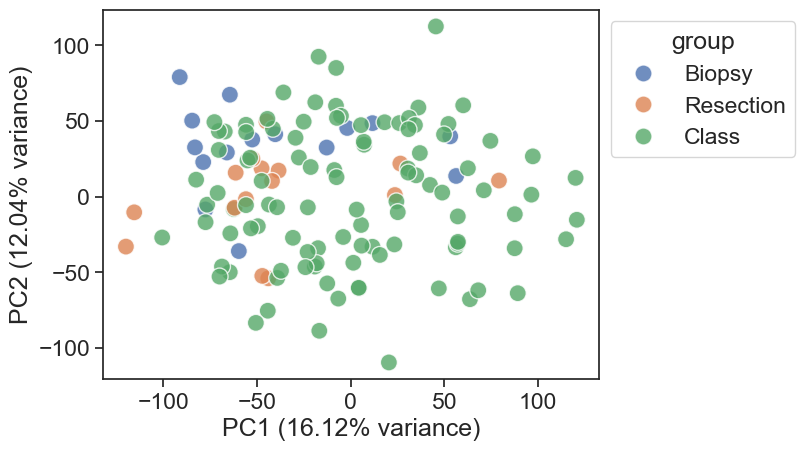

C:\Users\Fredrik\AppData\Local\Temp\ipykernel_7544\2662480432.py:21: UserWarning: 
The palette list has fewer values (1) than needed (15) and will cycle, which may produce an uninterpretable plot.
  h = sns.lineplot(df_pca[df_pca.patient_id != 'nan'], x='PC1', y='PC2', hue='patient_id', palette=sns.color_palette(['gray']), ax=ax)


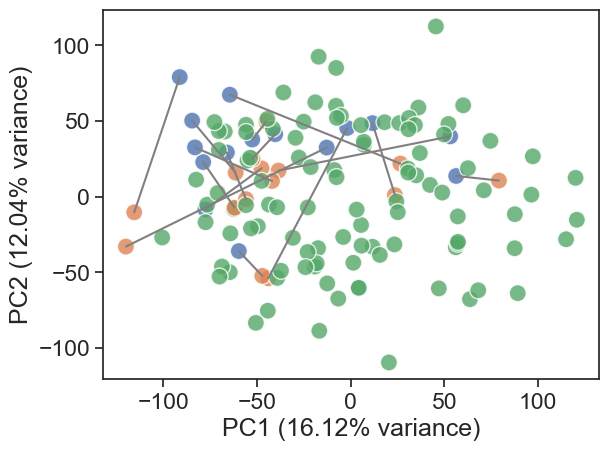

In [143]:
df_pca = pd.DataFrame(projections, columns=['PC1', 'PC2'], index=df_vst.columns)
df_pca['group'] = metadata.Sample_type
df_pca['patient_id'] = metadata['Patient ID'].astype(str)

# Overview
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2', hue='group', ax=ax, s=150, alpha=0.8, hue_order = hue_order)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
xlim = g.get_xlim()
ylim = g.get_ylim()
plt.savefig('PCA_classification_norm.pdf', bbox_inches='tight', dpi=300)
plt.show()
plt.close()


# Patients
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2', hue='group', ax=ax, s=150, alpha=0.8, hue_order=hue_order)
h = sns.lineplot(df_pca[df_pca.patient_id != 'nan'], x='PC1', y='PC2', hue='patient_id', palette=sns.color_palette(['gray']), ax=ax)
plt.legend([],[], frameon=False)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
plt.savefig('PCA_classification_pat_norm.pdf', bbox_inches='tight', dpi=300)
plt.show()
plt.close()
